## EDA Nutricional
Este notebook contiene el análisis del dataset obtenido tras la unión de los archivos con datos demográficos, médicos, nutricionales y las encuestas realizadas a los pacientes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nutrition_df = pd.read_csv("C:\\Users\\al_ce\\Documents\\CELIA\\master data analytics\\PROYECTO_FINAL\\DATA\\nutririon_processed\\nutrition_clean.csv")

In [3]:
#visión general
nutrition_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    8531 non-null   int64  
 1   gender                       8531 non-null   object 
 2   age                          8531 non-null   int64  
 3   race                         8531 non-null   object 
 4   country                      8531 non-null   object 
 5   education_level              8531 non-null   object 
 6   marital_status               8531 non-null   object 
 7   pregnancy_status             8531 non-null   object 
 8   household_size               8531 non-null   int64  
 9   household_income             8531 non-null   object 
 10  family_income                8531 non-null   float64
 11  family_poverty_ratio         8531 non-null   float64
 12  kcal                         8531 non-null   float64
 13  protein_g         

### Preguntas de Análisis
1. ¿Cómo influye la edad y el sexo en el consumo de macronutrientes y de kcal?
2. Relación de la actividad física y el consumo calórico.
3. ¿Existe relación entre la frecuencia de consumo de alcohol y los valores nutricionales?
4. Influencia del nivel económico de la familia en la dieta.
5. Relación entre las horas de sueño y el consumo de macronutrientes.


6. ¿Existe relación entre IMC y presión arterial?
7. ¿Las personas con mayor IMC consumen más kcal?


## 1. ¿Cómo influye la edad y el sexo en el consumo de macronutrientes y de kcal?


### 1.1 Sexo vs. consumo de macronutrientes

In [4]:
macros_by_gender = nutrition_df.pivot_table(
    values=["protein_g", "fat_g", "carb_g"],   #macronutrientes a considerar (carbohidratos, grasas y proteínas)
    index="gender",              #estudio mediante el género
    aggfunc="mean"               #se obtiene el consumo medio
)
macros_by_gender


,carb_g,fat_g,protein_g
gender,,,
Female,217.928245,66.958123,64.514915
Male,268.524633,83.560588,84.953815


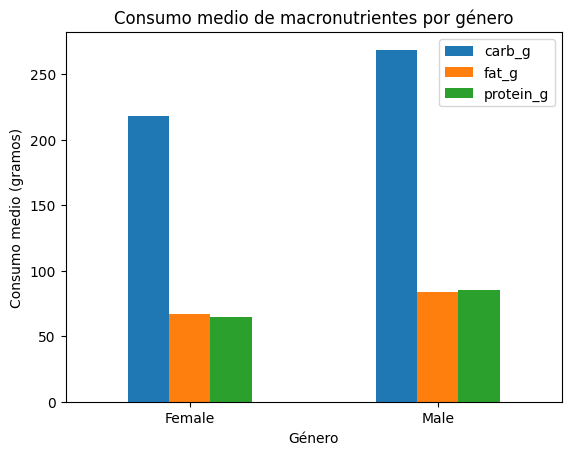

In [5]:
macros_by_gender.plot(kind="bar")
plt.xlabel("Género")
plt.ylabel("Consumo medio (gramos)")
plt.title("Consumo medio de macronutrientes por género")
plt.xticks(rotation=0)
plt.show()


El diagrama muestra que el consumo medio de macronutrientes en los hombres es superior al de las mujeres para cada uno de los nutrientes estudiados. Esta diferencia se aprecia de manera significativa en el caso de los carbohidratos.

### 1.2 Sexo vs. kcal

In [6]:
kcal_by_gender = nutrition_df.pivot_table(
    values=["kcal"],   
    index="gender",              
    aggfunc="mean"               
)
kcal_by_gender


,kcal
gender,
Female,1735.885235
Male,2202.211332


La tabla cruzada refleja que los hombres tienen un consumo medio de kcal superior al de las mujeres.

Las diferencias visualizadas en ambos análisis pueden estar relacionadas con una mayor ingesta calórica media en hombres debido a diferencias fisiológicas y de masa corporal, más que a patrones dietéticos distintos.

### 1.3 Edad vs. consumo de macronutrientes

De manera previa al estudio, se crea una nueva columna en nuestro dataframe con los intevalos según la edad del paciente.

In [7]:
nutrition_df["age_group"] = pd.cut(  #se hacen las divisiones según la edad
    nutrition_df["age"],              #tomamos los datos de las edades
    bins=[0, 18, 30, 45, 60, 120],     #se indica el límite superior de los intervalos
    labels=["0-18", "19-30", "31-45", "46-60", "60+"]   #se nombran los intervalos
)


In [8]:
macros_by_age_group = nutrition_df.pivot_table(
    values=["protein_g", "fat_g", "carb_g"],   
    index="age_group",              
    aggfunc="mean"               
)
macros_by_age_group

C:\Users\al_ce\AppData\Local\Temp\ipykernel_14236\1335663531.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  macros_by_age_group = nutrition_df.pivot_table(


,carb_g,fat_g,protein_g
age_group,,,
0-18,237.678221,68.509945,65.936072
19-30,274.974561,87.591721,89.474949
31-45,274.039696,85.411896,87.096941
46-60,250.712463,82.546573,83.754463
60+,219.859694,71.322279,72.012109


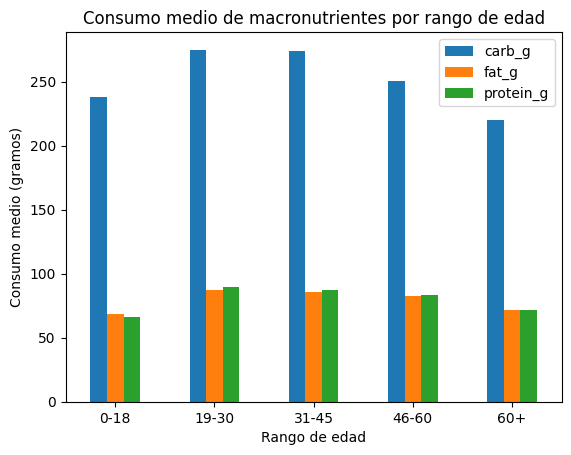

In [9]:
macros_by_age_group.plot(kind="bar")
plt.xlabel("Rango de edad")
plt.ylabel("Consumo medio (gramos)")
plt.title("Consumo medio de macronutrientes por rango de edad")
plt.xticks(rotation=0)
plt.show()

En el diagrama no se aprecian diferencias significativas en el consumo de macronutrientes según los rangos de edad; las barras están niveladas y las proporciones según el macronutriente son similares. Se observan valores ligeramente más elevados en el rango de edad adulta, entre 19 y 45 años lo que puede estar relacionado con un ritmo de vida más activo.

### 1.4 Edad vs. kcal

In [10]:
kcal_by_age_group = nutrition_df.pivot_table(
    values=["kcal"],   
    index="age_group",              
    aggfunc="mean"               
)
kcal_by_age_group

C:\Users\al_ce\AppData\Local\Temp\ipykernel_14236\2645071128.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  kcal_by_age_group = nutrition_df.pivot_table(


,kcal
age_group,
0-18,1812.705920
19-30,2303.320074
31-45,2269.504444
46-60,2125.922353
60+,1829.273469


La tabla cruzada permite intuir que no hay una gran influencia de edad en el consumo de calorías.

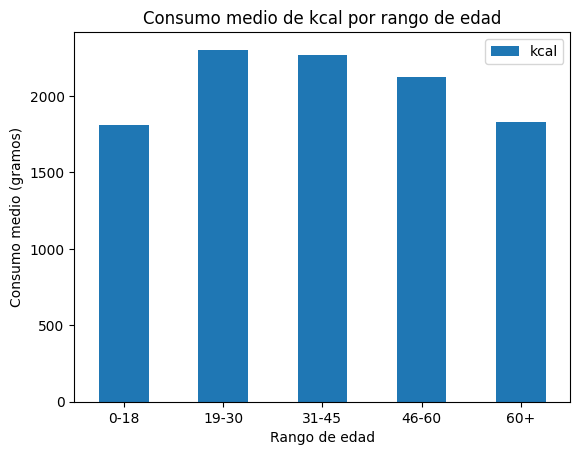

In [11]:
kcal_by_age_group.plot(kind="bar")
plt.xlabel("Rango de edad")
plt.ylabel("Consumo medio (gramos)")
plt.title("Consumo medio de kcal por rango de edad")
plt.xticks(rotation=0)
plt.show()

El diagrama muestra que el mayor consumo de kcal se da en el grupo de 19 a 45 años, en concreto en la franja de edad que abarca desde los 19 a los 30. Este resultado es coherente conla gráfica anterior y, en conjunto, se puede concluir que hay un mayor consumo calórico y nutricional en la edad adulta.

##  2. Relación de la actividad física y el consumo calórico.

In [12]:
kcal_by_mod_act = nutrition_df.pivot_table(
    values=["kcal"],   
    index="moderate_activity_day",        
    aggfunc="mean"   
)
kcal_by_mod_act


,kcal
moderate_activity_day,
Dont know,1635.500000
No,2034.512509
Refused,2011.000000
Unknown,1570.537171
Yes,2235.643765


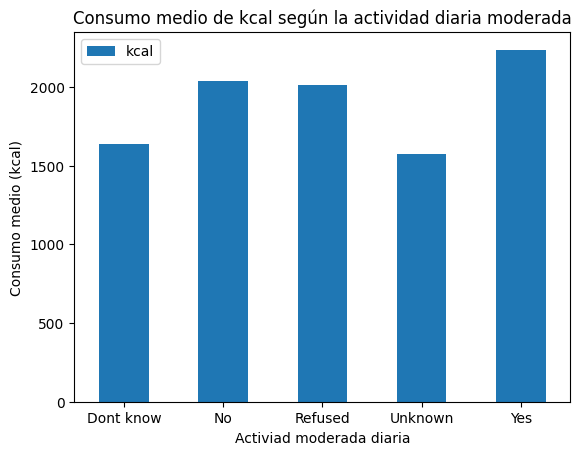

In [13]:
kcal_by_mod_act.plot(kind="bar")
plt.xlabel("Activiad moderada diaria")
plt.ylabel("Consumo medio (kcal)")
plt.title("Consumo medio de kcal según la actividad diaria moderada")
plt.xticks(rotation=0)
plt.show()

In [14]:
kcal_by_vig_act = nutrition_df.pivot_table(
    values=["kcal"],   
    index="vigorous_activity_day",        
    aggfunc="mean"   
)
kcal_by_vig_act

,kcal
vigorous_activity_day,
No,2037.657001
Refused,2011.000000
Unknown,1570.537171
Yes,2413.553604


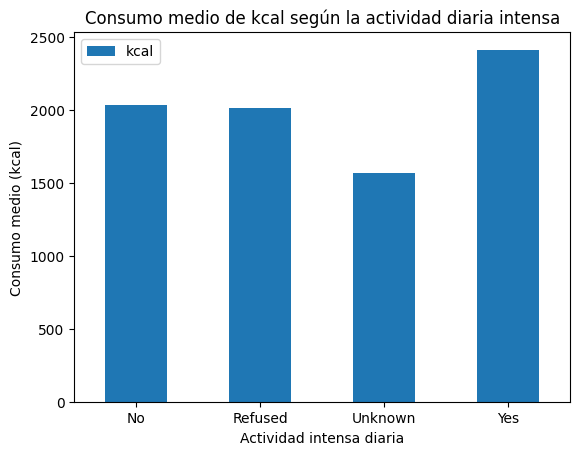

In [15]:
kcal_by_vig_act.plot(kind="bar")
plt.xlabel("Actividad intensa diaria")
plt.ylabel("Consumo medio (kcal)")
plt.title("Consumo medio de kcal según la actividad diaria intensa")
plt.xticks(rotation=0)
plt.show()

En ambos gráficos de barras se aprecia un mayor consumo diario de kcal en las personas que realizan actividad física, tanto moderada como intensa. Esta diferencia es más notable en el caso de la actividad intensa, lo que es coherente con mayores necesidades energéticas en personas físicamente activas. En el resto de categorías no se observan patrones claros en el consumo de kcal.

## 3. Existe relación entre el consumo de alcohol y los valores nutricionales.

### 3.1 Alcohol vs. kcal

In [16]:
kcal_by_alcohol = nutrition_df.pivot_table(
    values="kcal",
    index="alcohol_frequency",
    aggfunc="mean"
)
kcal_by_alcohol


,kcal
alcohol_frequency,
Monthly,2167.643716
Unknown,1795.876248
Weekly,2344.687770
Yearly,2096.004468


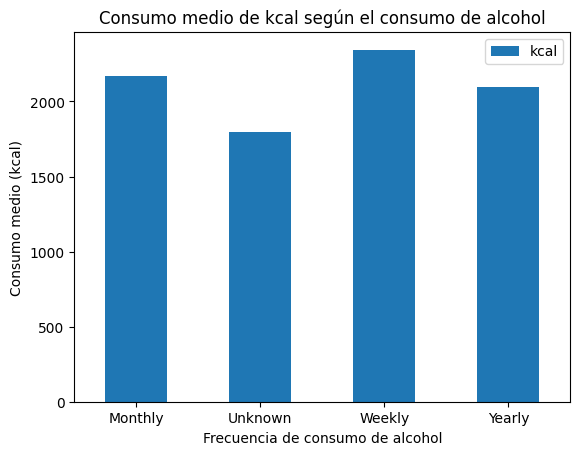

In [17]:
kcal_by_alcohol.plot(kind="bar")
plt.xlabel("Frecuencia de consumo de alcohol")
plt.ylabel("Consumo medio (kcal)")
plt.title("Consumo medio de kcal según el consumo de alcohol")
plt.xticks(rotation=0)
plt.show()

En el gráfico de barras anterior se observa que, aunque las diferencias en el consumo calórico no son considerables, sí se aprecian valores más elevados en aquellos encuestados que consumen alcohol semanalmente. Esto puede estar relacionado con hábitos alimenticios menos saludables aunque no es determinante.

### 3.2 Alcohol vs. macronutrientes

A continuación se estudia la relación entre los valores nutricionales con la frecuencia del consumo de alcohol. Estudiamos por separado la relación con los macronutrientes (en gramos) y el resto de nutrientes (en mg).

In [18]:
#tabla cruzada
macros_by_alcohol_frec = nutrition_df.pivot_table(
    values=["protein_g", "fat_g", "carb_g", "sugar_g", "total_monosat_fatty_acids_g","total_polysat_fatty_acids_g"],   
    index="alcohol_frequency",              
    aggfunc="mean"               
)
macros_by_alcohol_frec

,carb_g,fat_g,protein_g,sugar_g,total_monosat_fatty_acids_g,total_polysat_fatty_acids_g
alcohol_frequency,,,,,,
Monthly,259.411246,84.720230,83.876098,114.939891,29.372814,20.610248
Unknown,232.039113,68.680016,66.958120,106.836313,23.263219,15.629111
Weekly,258.518022,87.319345,89.310914,106.889043,30.887566,20.661583
Yearly,258.324808,81.345952,83.135603,118.947274,28.392862,18.764346


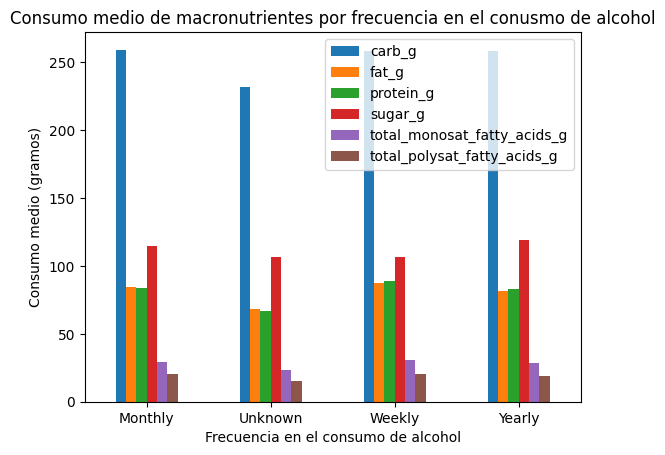

In [19]:
macros_by_alcohol_frec.plot(kind="bar")
plt.xlabel("Frecuencia en el consumo de alcohol")
plt.ylabel("Consumo medio (gramos)")
plt.title("Consumo medio de macronutrientes por frecuencia en el conusmo de alcohol")
plt.xticks(rotation=0)
plt.show()

El gráfico muestra distribuciones de los nutrientes similares en todas las categorías. Al compararlas entre sí, no se observan diferencias significativas según la frecuencia de consumo de alcohol, aunque sí se aprecian valores más elevados en los encuestados que consumen alcohol semanalmente.

Repetimos el estudio para otros nutrientes como el calcio, el colesterol y el magnesio. 

In [20]:
#tabla cruzada
others_by_alcohol_frec = nutrition_df.pivot_table(
    values=["calcium_mg", "magnesium_mg", "cholesterol_mg"],   
    index="alcohol_frequency",              
    aggfunc="mean"               
)
others_by_alcohol_frec

,calcium_mg,cholesterol_mg,magnesium_mg
alcohol_frequency,,,
Monthly,932.191257,309.911475,297.314754
Unknown,929.397102,229.260623,235.319170
Weekly,945.883453,320.698561,330.747482
Yearly,943.616622,302.138517,288.259160


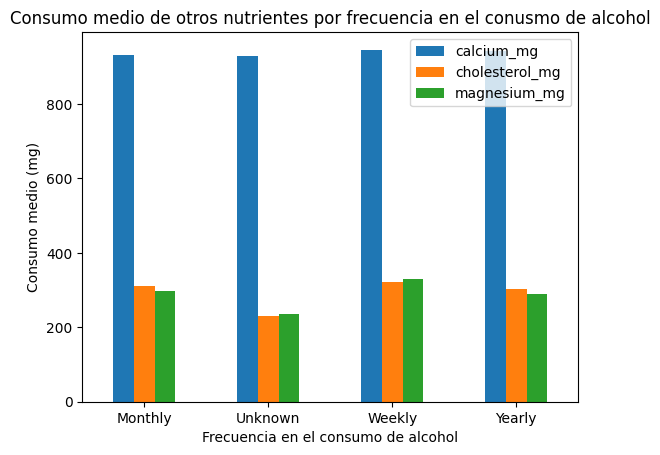

In [21]:
others_by_alcohol_frec.plot(kind="bar")
plt.xlabel("Frecuencia en el consumo de alcohol")
plt.ylabel("Consumo medio (mg)")
plt.title("Consumo medio de otros nutrientes por frecuencia en el conusmo de alcohol")
plt.xticks(rotation=0)
plt.show()

Al igual que en el estudio de macronutrientes, las distribuciones según las categorías son similares y no se observa un patrón claro. En el gráfico sí destaca la gran diferencia entre el consumo de calcio con respecto al colesterol y el magnesio, algo presente en todas las categorías.

Finalmente cabe destacar que el consumo de alcohol se mide en frecuencia y no en cantidad ingerida, lo que puede limitar la detección de relaciones más precisas.

## 4. Influencia del nivel económico de la familia en la dieta.

In [22]:
#tabla cruzada
macros_by_econom = nutrition_df.pivot_table(
    values=["protein_g", "fat_g", "carb_g", "sugar_g", "fiber_g"],   
    index="household_income",              
    aggfunc="mean"               
)
macros_by_econom

,carb_g,fat_g,fiber_g,protein_g,sugar_g
household_income,,,,,
"0 to 4,999 $",245.941907,69.582605,14.093953,71.857256,118.139535
"10,000 to 14,999 $",240.265077,74.887644,14.113602,70.863697,110.959444
"100,000 $ and Over",244.859530,77.228132,17.376949,79.166230,103.560659
"15,000 to 19,999 $",240.733455,70.924040,13.710238,66.945503,113.994296
"20,000 to 24,999 $",240.102918,72.980482,14.746452,71.947430,111.410710
"25,000 to 34,999 $",245.154319,74.335520,14.336831,71.960535,113.269173
"35,000 to 44,999 $",238.417760,74.283967,14.639800,75.162228,106.767159
"45,000 to 54,999 $",244.270831,77.210523,15.788462,76.003908,109.942308
"5,000 to 9,999\t$",238.807160,68.641834,13.264201,68.625089,112.690769


C:\Users\al_ce\AppData\Local\Temp\ipykernel_14236\1935635589.py:6: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\al_ce\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


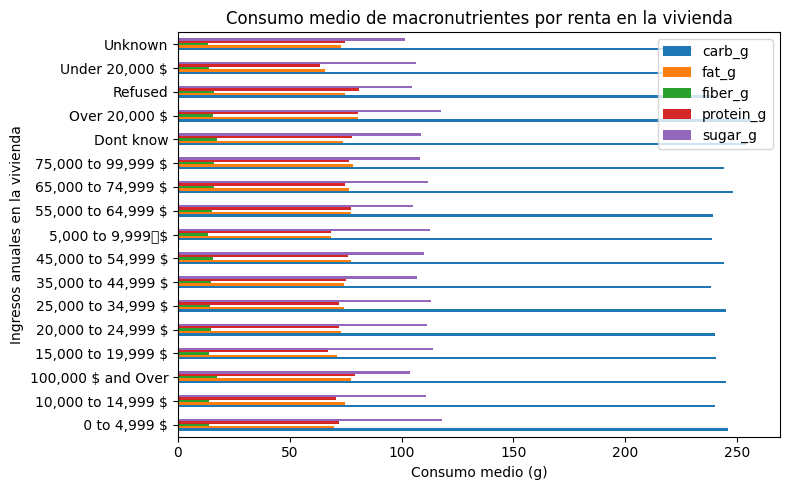

In [23]:
#optamos por un gráfico horizontal para poder distinguir mejor las categorías y la distribución que siguen las barras
macros_by_econom.plot(kind="barh", figsize=(8, 5))
plt.xlabel("Consumo medio (g)")
plt.ylabel("Ingresos anuales en la vivienda")
plt.title("Consumo medio de macronutrientes por renta en la vivienda")
plt.tight_layout()
plt.show()


Se opta por un gráfico de barras horizontales para ganar legibilidad y obtener una idea general de la distribución de los nutrientes. En este gráfico se aprecian distribuciones similares en todos los nutrientes, independientemente de las rentas de la vivienda. Esto sugiere que un mayor o menor nivel económico no tiene un impacto directo en el consumo de nutrientes, lo que representa un aspecto positivo.

## 5. Relación entre las horas de sueño y el consumo de macronutrientes.

In [24]:
#tabla cruzada
macros_by_sleep = nutrition_df.pivot_table(
    values=["protein_g", "fat_g", "carb_g", "sugar_g", "fiber_g"],   
    index="sleep_hours",              
    aggfunc="mean"               
)
macros_by_sleep

,carb_g,fat_g,fiber_g,protein_g,sugar_g
sleep_hours,,,,,
2.0,303.592857,87.904286,14.257143,91.158095,142.480952
3.0,238.110270,83.367027,12.197297,82.444865,117.935676
4.0,269.053571,82.315524,15.647619,77.375286,128.126905
5.0,258.072272,81.110406,15.908925,81.265375,117.640751
6.0,252.657553,83.372809,16.342093,82.808261,112.185535
7.0,232.240114,69.139155,14.047008,67.640868,105.755180
8.0,251.743109,80.412559,17.410237,82.916091,109.681747
9.0,253.880031,78.319875,16.618437,79.577188,112.620531
10.0,241.518561,80.729712,14.878417,75.282230,111.771799


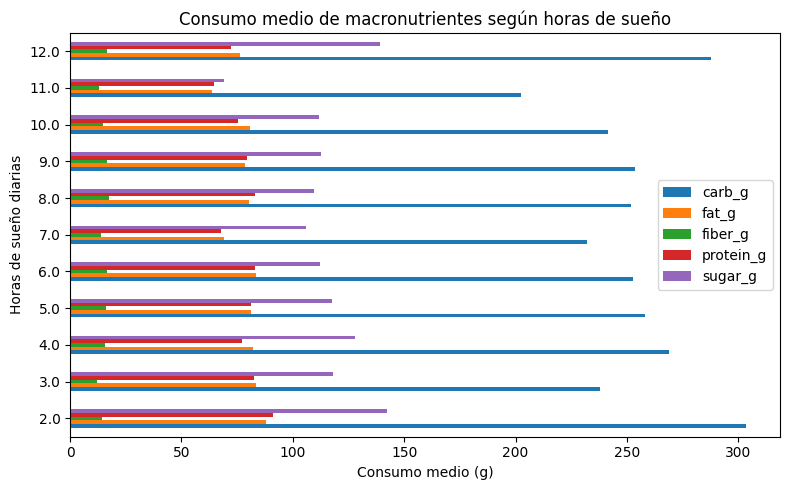

In [25]:
#optamos por un gráfico horizontal para poder distinguir mejor las categorías y la distribución que siguen las barras
macros_by_sleep.plot(kind="barh", figsize=(8, 5))
plt.xlabel("Consumo medio (g)")
plt.ylabel("Horas de sueño diarias")
plt.title("Consumo medio de macronutrientes según horas de sueño")
plt.tight_layout()
plt.show()


Se emplea un gráfico de barras horizontal dado que permite comparar mejor los resultados. Aunque las distribuciones son similares según las categorías, se aprecia un mayor consumo de carbohidratos y azúcar en aquellos sujetos con horas de sueño extremas, 2 y 12 horas. Esto sugiere que los pacientes con pocas horas de sueño acuden a alimentos con alto contenido en azúcar y carbohidratos para suplir las horas de sueño que no tienen, aunque esto no puede asegurarse por completo. Como esta característica se aprecia también en los pacientes con 12 horas de sueño, es posible que un sueño excesivo provoque un efecto contraproducente en el usuario.

In [26]:
sleep_propor = nutrition_df["sleep_hours"].value_counts(normalize=True) * 100
sleep_propor


sleep_hours
7.0     51.318720
8.0     18.321416
6.0     15.566757
5.0      5.778924
9.0      3.751026
4.0      2.461611
10.0     1.629352
3.0      0.433712
12.0     0.386825
2.0      0.246161
11.0     0.105498
Name: proportion, dtype: float64

La tabla anterior muestra el porcentaje de personas que duermen las horas indicadas. Dado que los valores extremos representan un número reducido de observaciones, las conclusiones anteriores deben interpretarse con cautela.

## 6. ¿Existe relación entre IMC y presión arterial?

### 6.1 Presión diastólica

In [27]:
#tabla cruzada
diastolic_by_bmi = nutrition_df.pivot_table(
    values=["diastolic_bp"],   #los valores que consideramos son los macronutrientes
    index="body_mass_index",              #queremos estudiar mediante las horas de sueño
    aggfunc="mean"               #obtenemos el consumo medio
)
diastolic_by_bmi

,diastolic_bp
body_mass_index,
12.1,66.0
12.3,58.0
12.6,57.0
12.7,66.0
12.9,66.0
...,...
67.9,80.0
68.6,86.0
70.1,86.0


In [28]:
#agrupo los índices de masa corporal para organizar los datos por categorías
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]

nutrition_df["bmi_group"] = pd.cut(
    nutrition_df["body_mass_index"],
    bins=bmi_bins,
    labels=bmi_labels
)

diastolic_by_bmi = nutrition_df.groupby("bmi_group")["diastolic_bp"].mean()  #Agrupa las personas según su categoría de IMC y calcula la presión diastólica media dentro de cada grupo



C:\Users\al_ce\AppData\Local\Temp\ipykernel_14236\2744861750.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diastolic_by_bmi = nutrition_df.groupby("bmi_group")["diastolic_bp"].mean()  #Agrupa las personas según su categoría de IMC y calcula la presión diastólica media dentro de cada grupo


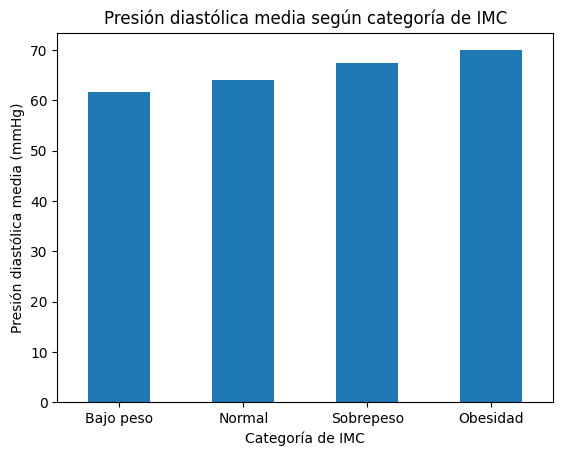

In [29]:
diastolic_by_bmi.plot(kind="bar")

plt.xlabel("Categoría de IMC")
plt.ylabel("Presión diastólica media (mmHg)")
plt.title("Presión diastólica media según categoría de IMC")
plt.xticks(rotation=0)
plt.show()


El gráfico muestra un aumento progresivo de la presión diastólica media a mayor índice de masa corporal. Para realizar una evaluación más profunda, se complementa el gráfico anterior con un boxplot.

<Figure size 640x480 with 0 Axes>

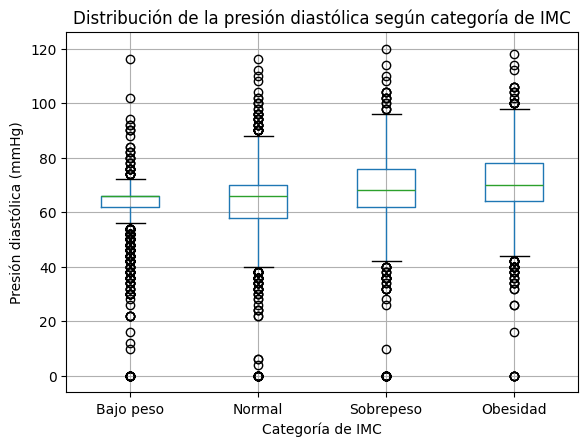

In [30]:
plt.figure()

nutrition_df.boxplot(
    column="diastolic_bp",
    by="bmi_group"
)

plt.xlabel("Categoría de IMC")
plt.ylabel("Presión diastólica (mmHg)")
plt.title("Distribución de la presión diastólica según categoría de IMC")
plt.suptitle("")  # elimino el título automático de pandas
plt.show()


Se observa un desplazamiento progresivo de la mediana de la presión diastólica hacia valores superiores a medida que aumenta el IMC. Además, el rango intercuartílico se amplía en las categorías superiores, lo que indica una mayor variabilidad en los valores de presión dentro de los grupos con mayor IMC.
Por otra parte, el grupo de bajo peso presenta un mayor número de valores atípicos, posiblemente debido a un menor tamaño muestral o a características particulares de los sujetos.
En cualquier caso, estos resultados sugieren una asociación entre IMC y presión diastólica.

### 6.2 Presión sistólica

In [31]:
#tabla cruzada
systolic_by_bmi = nutrition_df.pivot_table(
    values=["systolic_blood_pressure"],   #los valores que consideramos son los macronutrientes
    index="body_mass_index",              #queremos estudiar mediante las horas de sueño
    aggfunc="mean"               #obtenemos el consumo medio
)
systolic_by_bmi

,systolic_blood_pressure
body_mass_index,
12.1,116.0
12.3,86.0
12.6,104.0
12.7,116.0
12.9,116.0
...,...
67.9,134.0
68.6,124.0
70.1,128.0


In [32]:
#agrupo los índices de masa corporal para organizar los datos por categorías
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]

nutrition_df["bmi_group"] = pd.cut(
    nutrition_df["body_mass_index"],
    bins=bmi_bins,
    labels=bmi_labels
)

systolic_by_bmi = nutrition_df.groupby("bmi_group")["systolic_blood_pressure"].mean() 



C:\Users\al_ce\AppData\Local\Temp\ipykernel_14236\2383039016.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  systolic_by_bmi = nutrition_df.groupby("bmi_group")["systolic_blood_pressure"].mean()


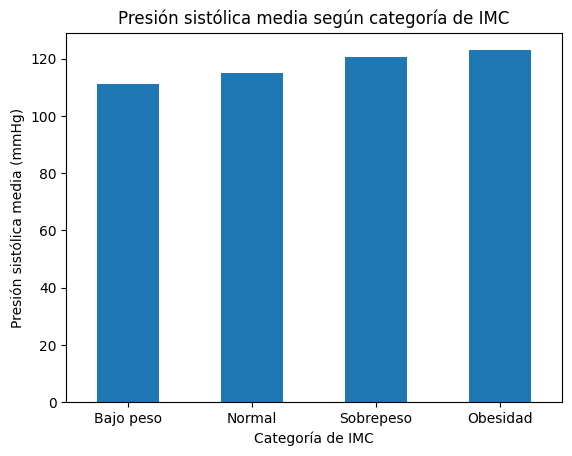

In [33]:
systolic_by_bmi.plot(kind="bar")

plt.xlabel("Categoría de IMC")
plt.ylabel("Presión sistólica media (mmHg)")
plt.title("Presión sistólica media según categoría de IMC")
plt.xticks(rotation=0)
plt.show()

La gráfica muestra el mismo aumento progresivo de la presión sistólica que hemos observado en la diastólica.

<Figure size 640x480 with 0 Axes>

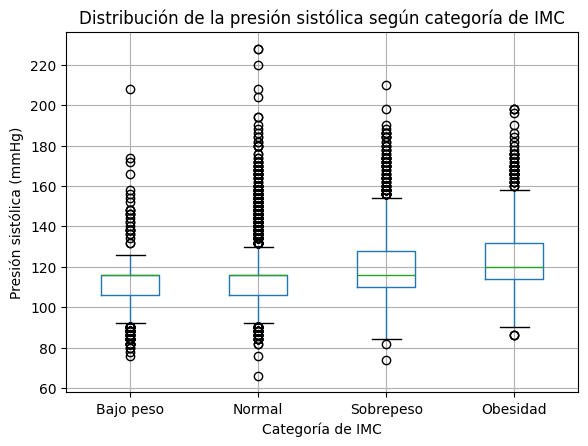

In [34]:
plt.figure()

nutrition_df.boxplot(
    column="systolic_blood_pressure",
    by="bmi_group"
)

plt.xlabel("Categoría de IMC")
plt.ylabel("Presión sistólica (mmHg)")
plt.title("Distribución de la presión sistólica según categoría de IMC")
plt.suptitle("")  # elimino el título automático de pandas
plt.show()


En el boxplot correspondiente a la presión sistólica se observa igualmente una tendencia creciente de la mediana conforme aumenta el IMC, aunque el patrón resulta más sutil que en la presión diastólica, ya que en las dos primeras categorías las medianas presentan valores muy similares.

Se aprecia además la presencia de valores atípicos en la categoría de IMC normal, lo que podría reflejar variabilidad individual o la influencia de factores no considerados en este análisis.

En conjunto, la comparación de ambos gráficos sugiere que las diferencias entre categorías de IMC son ligeramente más pronunciadas en la presión diastólica que en la sistólica.

## 7. Relación entre el consumo de kcal y el IMC

In [35]:
#tabla cruzada
kcal_by_bmi = nutrition_df.pivot_table(
    values=["kcal"],   #los valores que consideramos son los macronutrientes
    index="body_mass_index",              #queremos estudiar mediante las horas de sueño
    aggfunc="mean"               #obtenemos el consumo medio
)
kcal_by_bmi

,kcal
body_mass_index,
12.1,1307.000000
12.3,1246.000000
12.6,990.500000
12.7,1878.000000
12.9,1363.333333
...,...
67.9,2602.000000
68.6,1453.000000
70.1,1364.000000


In [36]:
#agrupo los índices de masa corporal para organizar los datos por categorías
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]

nutrition_df["bmi_group"] = pd.cut(
    nutrition_df["body_mass_index"],
    bins=bmi_bins,
    labels=bmi_labels
)

kcal_by_bmi = nutrition_df.groupby("bmi_group")["kcal"].mean() 


C:\Users\al_ce\AppData\Local\Temp\ipykernel_14236\3357976152.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kcal_by_bmi = nutrition_df.groupby("bmi_group")["kcal"].mean()


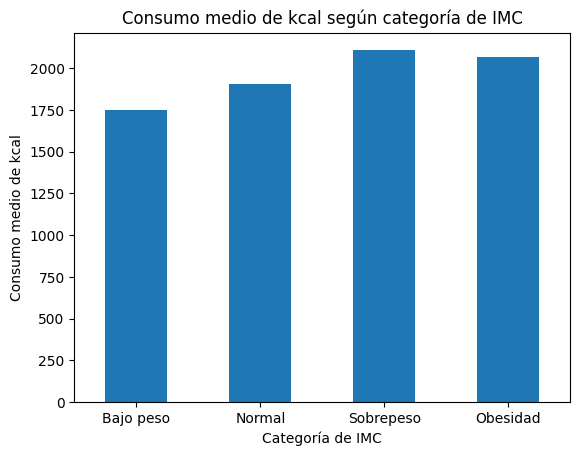

In [37]:
kcal_by_bmi.plot(kind="bar")

plt.xlabel("Categoría de IMC")
plt.ylabel("Consumo medio de kcal")
plt.title("Consumo medio de kcal según categoría de IMC")
plt.xticks(rotation=0)
plt.show()

Como era de esperar, en las categorías de personas con sobrepeso y obesidad se observa un mayor consumo medio de kcal. Sin embargo, el gráfico sugiere que el consumo de kcal no es un factor único ni determinante en el aumneto de peso, puesto que las diferencias entre categorías no son determinantes.

## Conclusión final

El estudio realizado permite identificar tendencias coherentes, como un mayor consumo energético y nutricional en los sujetos masculinos y en personas en rango de edad adulto. Asimismo, se observa la relevancia de la actividad física en el consumo calórico, siendo este mayor en individuos más activos, lo que resulta consistente con mayores requerimientos energéticos.

Por otro lado, determinadas variables como el consumo de alcohol o el nivel económico no muestran diferencias sistemáticas en los patrones analizados. En contraste, se aprecia una relación descriptiva más clara entre el IMC y la presión arterial, evidenciándose valores más elevados de presión en rangos superiores de IMC. Del mismo modo, se observa una tendencia a mayores valores de IMC en contextos de mayor consumo calórico, si bien este no constituye el único factor implicado en la ganancia de peso.

Debe señalarse que el presente análisis es de carácter exploratorio y descriptivo, por lo que no permite establecer relaciones causales entre las variables estudiadas. No obstante, los hallazgos obtenidos permiten identificar áreas de interés relevantes para análisis posteriores y para la construcción del dashboard interactivo

## Vinculación con Power BI
Los resultados obtenidos en esta fase exploratoria han permitido identificar las variables con mayor interés analítico, especialmente el IMC y la presión arterial, así como los patrones asociados a la actividad física. Estos hallazgos servirán como base para el diseño del dashboard interactivo que se desarrollará posteriormente en Power BI, orientado a la visualización y exploración dinámica de dichas relaciones.

In [38]:
nutrition_df.to_csv("nutrition_clean.csv", index=False)
